In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import nflreadpy as nfl
import seaborn as sns
import numpy as np

In [3]:
pbp = nfl.load_pbp([2020, 2021, 2022, 2023, 2024, 2025])
pbp.head()

play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,side_of_field,yardline_100,game_date,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,game_half,quarter_end,drive,sp,qtr,down,goal_to_go,time,yrdln,ydstogo,ydsnet,desc,play_type,yards_gained,shotgun,no_huddle,qb_dropback,qb_kneel,qb_spike,qb_scramble,pass_length,…,home_coach,away_coach,stadium_id,game_stadium,aborted_play,success,passer,passer_jersey_number,rusher,rusher_jersey_number,receiver,receiver_jersey_number,pass,rush,first_down,special,play,passer_id,rusher_id,receiver_id,name,jersey_number,id,fantasy_player_name,fantasy_player_id,fantasy,fantasy_id,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
f64,str,str,str,str,str,i32,str,str,str,str,f64,str,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,str,str,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,str,…,str,str,str,str,f64,f64,str,i32,str,i32,str,i32,f64,f64,f64,f64,f64,str,str,str,str,i32,str,str,str,str,str,f64,f64,f64,f64,f64,i32,f64,f64,f64,f64
1.0,"""2020_01_ARI_SF""","""2020091311""","""SF""","""ARI""","""REG""",1,null,null,null,null,null,"""2020-09-13""",900.0,1800.0,3600.0,"""Half1""",0.0,null,0.0,1.0,null,0.0,"""15:00""","""ARI 35""",0.0,null,"""GAME""",null,null,0.0,0.0,null,0.0,0.0,0.0,null,…,"""Kyle Shanahan""","""Kliff Kingsbury""","""SFO01""","""Levi's Stadium""",0.0,0.0,null,null,null,null,null,null,0.0,0.0,null,0.0,0.0,null,null,null,null,null,null,null,null,null,null,0.0,1.0,0.0,null,null,null,null,null,null,null
39.0,"""2020_01_ARI_SF""","""2020091311""","""SF""","""ARI""","""REG""",1,"""SF""","""home""","""ARI""","""ARI""",35.0,"""2020-09-13""",900.0,1800.0,3600.0,"""Half1""",0.0,1.0,0.0,1.0,null,0.0,"""15:00""","""ARI 35""",0.0,41.0,"""5-Z.Gonzalez kicks 65 yards fr…","""kickoff""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,…,"""Kyle Shanahan""","""Kliff Kingsbury""","""SFO01""","""Levi's Stadium""",0.0,0.0,null,null,null,null,null,null,0.0,0.0,0.0,1.0,0.0,null,null,null,null,null,null,null,null,null,null,0.0,1.0,0.0,null,null,null,null,null,null,null
54.0,"""2020_01_ARI_SF""","""2020091311""","""SF""","""ARI""","""REG""",1,"""SF""","""home""","""ARI""","""SF""",75.0,"""2020-09-13""",900.0,1800.0,3600.0,"""Half1""",0.0,1.0,0.0,1.0,1.0,0.0,"""15:00""","""SF 25""",10.0,41.0,"""(15:00) (Shotgun) 10-J.Garoppo…","""pass""",5.0,1.0,0.0,1.0,0.0,0.0,0.0,"""short""",…,"""Kyle Shanahan""","""Kliff Kingsbury""","""SFO01""","""Levi's Stadium""",0.0,1.0,"""J.Garoppolo""",10,null,null,"""G.Kittle""",85,1.0,0.0,1.0,0.0,1.0,"""00-0031345""",null,"""00-0033288""","""J.Garoppolo""",10,"""00-0031345""","""G.Kittle""","""00-0033288""","""G.Kittle""","""00-0033288""",0.0,1.0,1.294838,0.50337,4.275047,2,0.619306,0.239695,0.515058,48.494154
93.0,"""2020_01_ARI_SF""","""2020091311""","""SF""","""ARI""","""REG""",1,"""SF""","""home""","""ARI""","""SF""",55.0,"""2020-09-13""",882.0,1782.0,3582.0,"""Half1""",0.0,1.0,0.0,1.0,1.0,0.0,"""14:42""","""SF 45""",10.0,41.0,"""(14:42) (Shotgun) 31-R.Mostert…","""run""",14.0,1.0,0.0,0.0,0.0,0.0,0.0,null,…,"""Kyle Shanahan""","""Kliff Kingsbury""","""SFO01""","""Levi's Stadium""",0.0,1.0,null,null,"""R.Mostert""",31,null,null,0.0,1.0,1.0,0.0,1.0,null,"""00-0031687""",null,"""R.Mostert""",31,"""00-0031687""","""R.Mostert""","""00-0031687""","""R.Mostert""","""00-0031687""",0.0,1.0,0.857214,null,null,null,null,null,0.413357,-41.335732
118.0,"""2020_01_ARI_SF""","""2020091311""","""SF""","""ARI""","""REG""",1,"""SF""","""home""","""ARI""","""ARI""",41.0,"""2020-09-13""",839.0,1739.0,3539.0,"""Half1""",0.0,1.0,0.0,1.0,1.0,0.0,"""13:59""","""ARI 41""",10.0,41.0,"""(13:59) 31-R.Mostert left end …","""run""",2.0,0.0,0.0,0.0,0.0,0.0,0.0,null,…,"""Kyle Shanahan""","""Kliff Kingsbury""","""SFO01""","""Levi's Stadium""",0.0,0.0,null,null,"""R.Mostert""",31,null,null,0.0,1.0,0.0,0.0,1.0,null,"""00-0031687""",null,"""R.Mostert""",31,"""00-0031687""","""R.Mostert""","""00-0031687

In [4]:
pbp = pbp.to_pandas()

In [5]:
df = pbp[
    (pbp["season_type"] == "REG") &
    (pbp["down"] == 4) &
    (pbp["play_type"].isin(["run", "pass"]))
].copy()

print("Total 4th Down Attempts:", len(df))
df.head()

Total 4th Down Attempts: 4622


,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
49,1268.0,2020_01_ARI_SF,2020091311,SF,ARI,REG,1,SF,home,ARI,...,0.0,1.0,-4.137538,NaN,NaN,NaN,NaN,NaN,0.335994,-33.599368
179,4508.0,2020_01_ARI_SF,2020091311,SF,ARI,REG,1,SF,home,ARI,...,0.0,1.0,-2.542086,0.433449,2.289571,1.0,0.99651,0.99651,0.964711,3.528941
206,368.0,2020_01_CHI_DET,2020091304,DET,CHI,REG,1,CHI,away,DET,...,0.0,0.0,-3.245736,0.269777,3.895141,2.0,1.00000,1.00000,0.967410,3.258961
320,3131.0,2020_01_CHI_DET,2020091304,DET,CHI,REG,1,CHI,away,DET,...,1.0,0.0,1.748239,NaN,NaN,NaN,NaN,NaN,0.291079,-29.107934
402,478.0,2020_01_CLE_BAL,2020091301,BAL,CLE,REG,1,CLE,away,BAL,...,0.0,0.0,-3.302165,NaN,NaN,NaN,NaN,NaN,0.566884,-56.688362


In [6]:
print(df.columns.tolist())

['play_id', 'game_id', 'old_game_id', 'home_team', 'away_team', 'season_type', 'week', 'posteam', 'posteam_type', 'defteam', 'side_of_field', 'yardline_100', 'game_date', 'quarter_seconds_remaining', 'half_seconds_remaining', 'game_seconds_remaining', 'game_half', 'quarter_end', 'drive', 'sp', 'qtr', 'down', 'goal_to_go', 'time', 'yrdln', 'ydstogo', 'ydsnet', 'desc', 'play_type', 'yards_gained', 'shotgun', 'no_huddle', 'qb_dropback', 'qb_kneel', 'qb_spike', 'qb_scramble', 'pass_length', 'pass_location', 'air_yards', 'yards_after_catch', 'run_location', 'run_gap', 'field_goal_result', 'kick_distance', 'extra_point_result', 'two_point_conv_result', 'home_timeouts_remaining', 'away_timeouts_remaining', 'timeout', 'timeout_team', 'td_team', 'td_player_name', 'td_player_id', 'posteam_timeouts_remaining', 'defteam_timeouts_remaining', 'total_home_score', 'total_away_score', 'posteam_score', 'defteam_score', 'score_differential', 'posteam_score_post', 'defteam_score_post', 'score_differential

In [7]:
print(
    df[
        ["fourth_down_converted", "fourth_down_failed"]
    ].value_counts(dropna=False)
)

fourth_down_converted  fourth_down_failed
1.0                    0.0                   2491
0.0                    1.0                   2129
                       0.0                      2
Name: count, dtype: int64


In [8]:
df = df[
    (df["fourth_down_converted"] == 1) |
    (df["fourth_down_failed"] == 1)
].copy()

df["converted"] = df["fourth_down_converted"].astype(int)

print(df["converted"].value_counts())

print(
    "Overall conversion rate:",
    round(df["converted"].mean() * 100, 2),
    "%"
)

converted
1    2491
0    2129
Name: count, dtype: int64
Overall conversion rate: 53.92 %


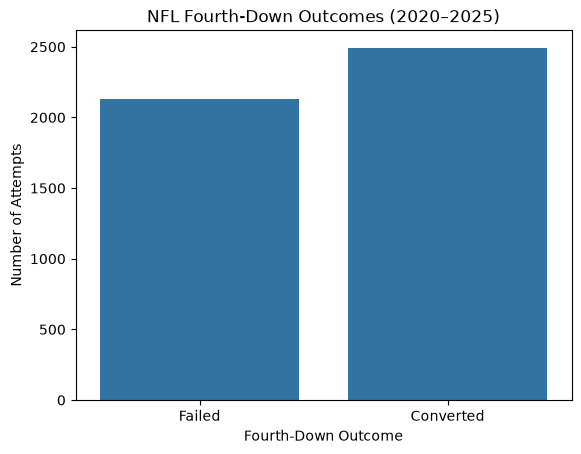

In [9]:
sns.countplot(
    data=df,
    x="converted"
)

plt.title("NFL Fourth-Down Outcomes (2020–2025)")
plt.xlabel("Fourth-Down Outcome")
plt.ylabel("Number of Attempts")
plt.xticks([0, 1], ["Failed", "Converted"])

plt.show()

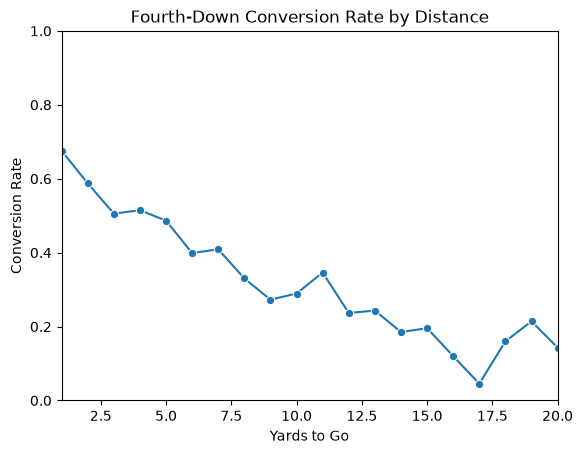

In [10]:
distance = (
    df.groupby("ydstogo")["converted"]
    .agg(["mean", "count"])
    .reset_index()
)

distance = distance[distance["count"] >= 10]

sns.lineplot(
    data=distance,
    x="ydstogo",
    y="mean",
    marker="o"
)

plt.title("Fourth-Down Conversion Rate by Distance")
plt.xlabel("Yards to Go")
plt.ylabel("Conversion Rate")
plt.xlim(1, 20)
plt.ylim(0, 1)

plt.show()

In [11]:
features = ["ydstogo", "yardline_100", "score_differential", "qtr", "game_seconds_remaining"]

model_df = df[features + ["converted", "season"]].dropna().copy()

X = model_df[features]
y = model_df["converted"]

print("Total observations:", len(model_df))
print("\nMissing values:")
print(model_df.isnull().sum())

X.head()

Total observations: 4620

Missing values:
ydstogo                   0
yardline_100              0
score_differential        0
qtr                       0
game_seconds_remaining    0
converted                 0
season                    0
dtype: int64


,ydstogo,yardline_100,score_differential,qtr,game_seconds_remaining
49,1.0,1.0,3.0,2.0,2557.0
179,5.0,16.0,-4.0,4.0,37.0
206,7.0,34.0,0.0,1.0,3242.0
320,1.0,10.0,-17.0,4.0,900.0
402,4.0,69.0,-7.0,1.0,3077.0


In [12]:
train = model_df["season"] < 2025
test = model_df["season"] == 2025

X_train = X.loc[train]
X_test = X.loc[test]

y_train = y.loc[train]
y_test = y.loc[test]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining conversion rate:", y_train.mean())
print("Testing conversion rate:", y_test.mean())

Training observations: 3738
Testing observations: 882

Training conversion rate: 0.5355805243445693
Testing conversion rate: 0.5544217687074829


In [13]:
model = DecisionTreeClassifier(max_depth=4, min_samples_leaf=30, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

print(classification_report(y_test, y_pred, zero_division=0))

Model Accuracy: 63.95%
              precision    recall  f1-score   support

           0       0.67      0.38      0.48       393
           1       0.63      0.85      0.72       489

    accuracy                           0.64       882
   macro avg       0.65      0.61      0.60       882
weighted avg       0.65      0.64      0.62       882



In [15]:
majority_class = y_train.mode()[0]

baseline_pred = np.full(len(y_test), majority_class)

baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"Baseline Accuracy: {baseline_accuracy:.2%}")
print(f"Decision Tree Accuracy: {accuracy:.2%}")

Baseline Accuracy: 55.44%
Decision Tree Accuracy: 63.95%


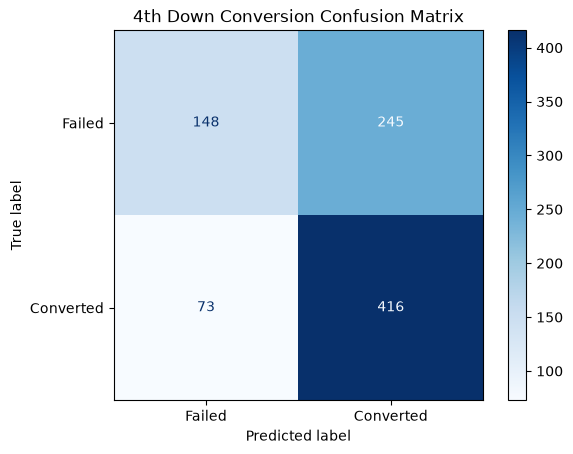

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Failed", "Converted"], cmap="Blues")
plt.title("4th Down Conversion Confusion Matrix")
plt.show()

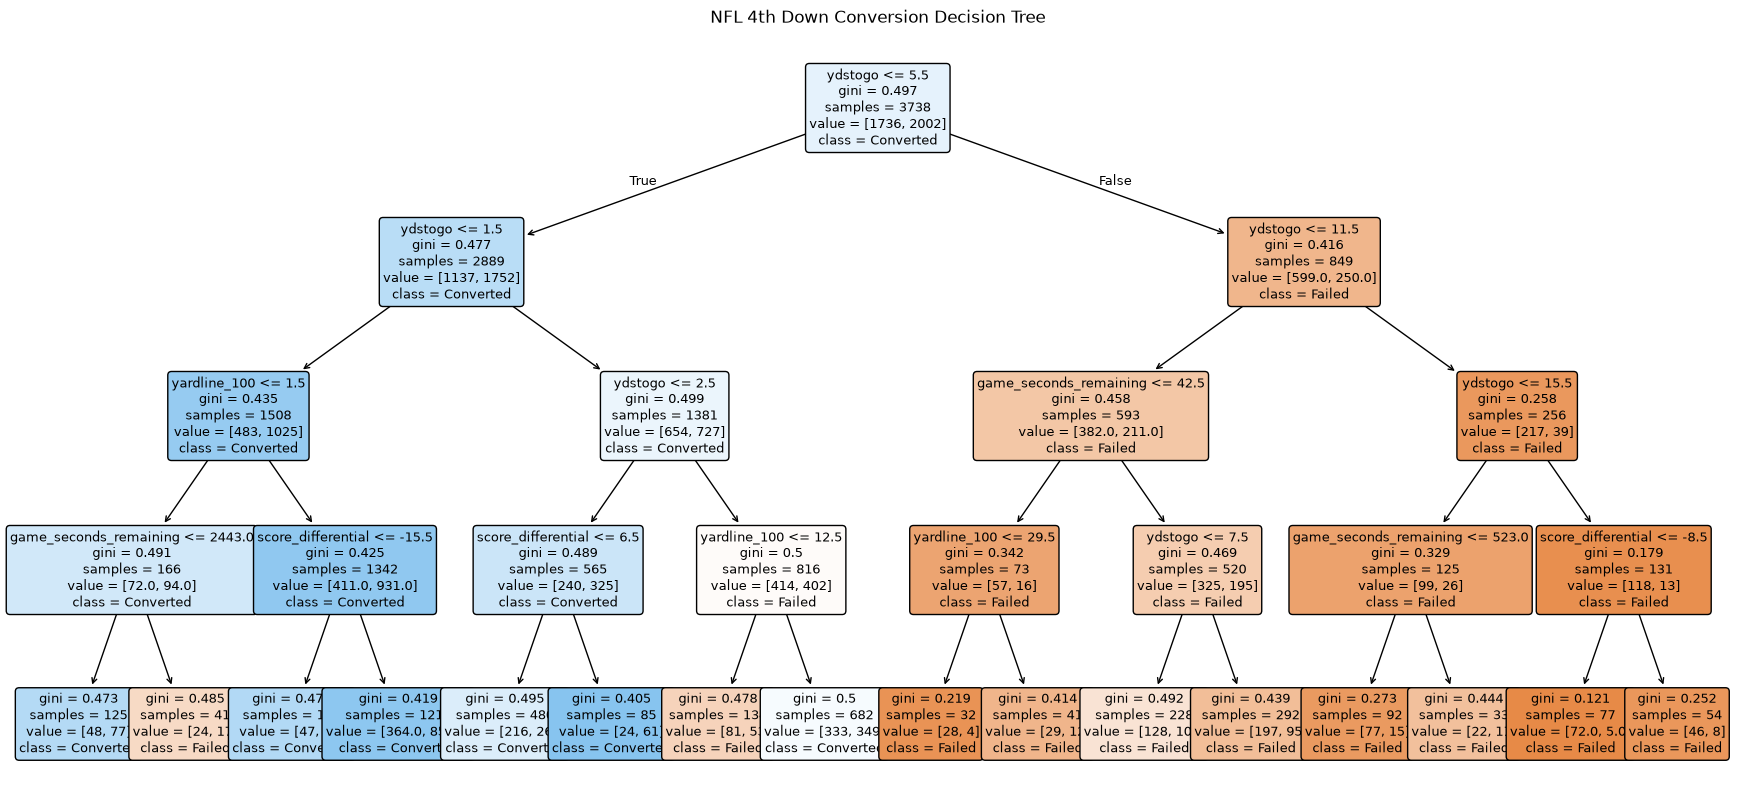

In [17]:
plt.figure(figsize=(22, 10))

plot_tree(model, feature_names=features, class_names=["Failed", "Converted"], filled=True, rounded=True, fontsize=9)

plt.title("NFL 4th Down Conversion Decision Tree")
plt.show()

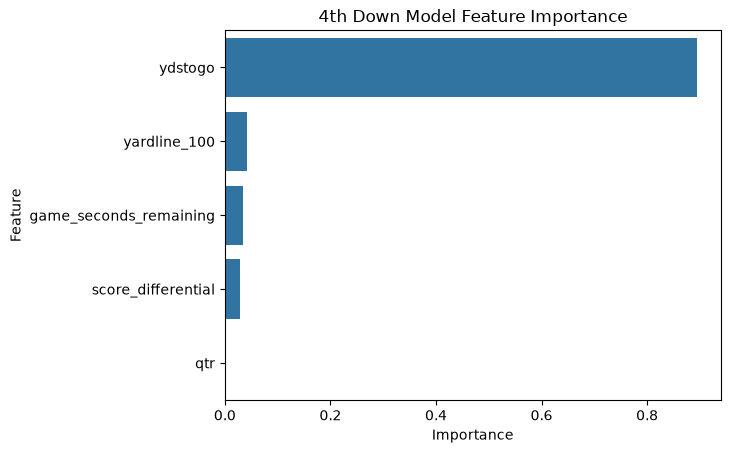

In [18]:
importance = pd.DataFrame({"Feature": features, "Importance": model.feature_importances_})

importance = importance.sort_values("Importance", ascending=False)

sns.barplot(data=importance, x="Importance", y="Feature")

plt.title("4th Down Model Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [19]:
y_prob = model.predict_proba(X_test)[:, 1]

results = X_test.copy()

results["actual"] = y_test
results["predicted"] = y_pred
results["conversion_probability"] = y_prob

results.head(10)

,ydstogo,yardline_100,score_differential,qtr,game_seconds_remaining,actual,predicted,conversion_probability
246394,1.0,24.0,-7.0,4.0,26.0,1,1,0.701149
246398,10.0,18.0,-7.0,4.0,4.0,0,0,0.125000
246559,2.0,10.0,-15.0,4.0,245.0,1,1,0.550000
246596,1.0,63.0,0.0,1.0,3527.0,1,1,0.701149
246689,1.0,5.0,-17.0,3.0,1491.0,0,1,0.620968
246713,5.0,33.0,-17.0,3.0,923.0,0,1,0.511730
246722,1.0,34.0,17.0,4.0,644.0,1,1,0.701149
246785,1.0,48.0,-7.0,1.0,2951.0,1,1,0.701149
246800,1.0,1.0,-7.0,2.0,2564.0,1,0,0.414634
246882,5.0,39.0,-1.0,4.0,856.0,0,1,0.511730


In [20]:
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss

print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 3))
print("Log Loss:", round(log_loss(y_test, y_prob), 3))
print("Brier Score:", round(brier_score_loss(y_test, y_prob), 3))

ROC AUC: 0.656
Log Loss: 0.646
Brier Score: 0.227


## Model 2: Logistic Regression

The second model tested is Logistic Regression. The model will predict whether a fourth-down attempt is converted (1) or fails (0).

In [21]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [22]:
log_pred = log_model.predict(X_test)

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

print("Accuracy:", round(log_accuracy, 3))
print("Precision:", round(log_precision, 3))
print("Recall:", round(log_recall, 3))
print("F1 Score:", round(log_f1, 3))

Accuracy: 0.635
Precision: 0.627
Recall: 0.84
F1 Score: 0.719


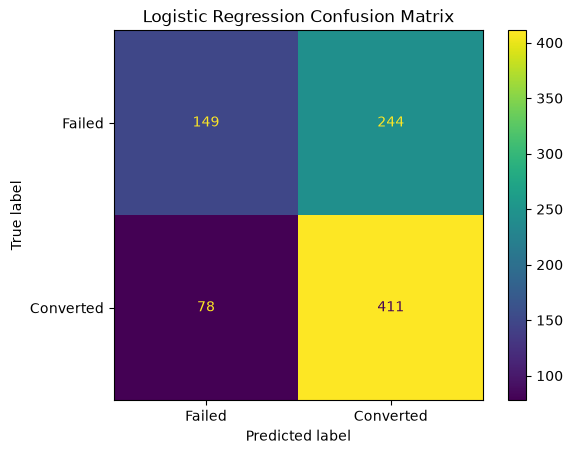

In [24]:
ConfusionMatrixDisplay.from_predictions(y_test, log_pred, display_labels=["Failed", "Converted"])
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [26]:
tree_accuracy = accuracy_score(y_test, y_pred)
tree_precision = precision_score(y_test, y_pred)
tree_recall = recall_score(y_test, y_pred)
tree_f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(tree_accuracy, 3))
print("Precision:", round(tree_precision, 3))
print("Recall:", round(tree_recall, 3))
print("F1 Score:", round(tree_f1, 3))

Accuracy: 0.639
Precision: 0.629
Recall: 0.851
F1 Score: 0.723


In [28]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Decision Tree", "Logistic Regression"],
    "Accuracy": [baseline_accuracy, tree_accuracy, log_accuracy],
    "Precision": [None, tree_precision, log_precision],
    "Recall": [None, tree_recall, log_recall],
    "F1 Score": [None, tree_f1, log_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.554422,NaN,NaN,NaN
1,Decision Tree,0.639456,0.629349,0.850716,0.723478
2,Logistic Regression,0.634921,0.627481,0.840491,0.718531
